# AI-Engram - CelebA / ResNet-WAE attribute arithmetic (self-contained, Colab-ready)

A ResNet **WAE** trained on CelebA is edited *surgically* so a facial attribute
(e.g. **Eyeglasses**, **Goatee**) is **added** or **removed** from the reconstruction.

**How to use this notebook**
1. **`sweep(attr, alphas)`** - inspect one attribute across edit strengths. By default the
   faces shown are ones that **have** the attribute (`label=1`), so you can see it both
   **intensify** (alpha &lt; 0) and **disappear** (alpha &gt; 0). Pick a strength that looks clean.
2. **`show(attr, alpha, has_attr=...)`** - single-attribute demo.
   `show('Eyeglasses', +0.3)` removes glasses from real glasses-wearers;
   `show('Eyeglasses', -0.3, has_attr=False)` adds glasses to bare faces.
3. **`arithmetic(add, sub, ...)`** - the combined `+add -sub` figure.

Every figure prints the **column index** on the top row, so pass e.g. `select=[0, 3, 7]`
to keep only the samples that came out well.

**Self-contained design** - engram modules (`method`, `models/wae`, `data/celeba`, `metric`)
are inlined **verbatim**; the only external package is **`pythae`** (WAE architecture +
HF checkpoint loader); the WAE checkpoint and CelebA are downloaded automatically.

**Not identical to the paper (on purpose).** The paper loads ~2 GB of pre-computed covariance
matrices; here we recompute them on the fly over CelebA subsets, so the edit strength is
retuned (the paper's 4/3 over-edits the recomputed direction).

In [1]:
# The one external dependency: pythae (WAE architecture + HF-Hub checkpoint loader).
# torch / torchvision / matplotlib / numpy are already present on Colab.
import importlib, subprocess, sys
if importlib.util.find_spec("pythae") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pythae"], check=True)
import pythae
print("pythae ready")

pythae ready


In [2]:
# ===== engram/method/__init__.py  (verbatim from the engram package) =====
import torch
import torch.nn as nn

import os
import inspect
from tqdm import tqdm
from copy import deepcopy
import gc
    
@torch.inference_mode()
def get_cov_matrix(model, dataloader, device=None, dtype=torch.float32, batch_fn=None, verbose=True):
    device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval().to(device)
   
    handles = []
    cov_matrix = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            cov_matrix[name] = torch.zeros((module.in_features, module.in_features), device=device, dtype=dtype)
            def pre_hook_fn(module=module, name=name):
                def hook(module_hook, inputs):
                    x = inputs[0].to(device)
                    x = x.reshape(-1, module.in_features)
                    cov_matrix[name] += x.mT @ x
                    return inputs
                return hook
            handle = module.register_forward_pre_hook(pre_hook_fn())
            handles.append(handle)
       
        elif isinstance(module, nn.Conv2d):
            d = int(module.in_channels * module.kernel_size[0] * module.kernel_size[1])
            cov_matrix[name] = torch.zeros((d, d), device=device, dtype=dtype)
            def pre_hook_fn(module=module, name=name):
                unfold = nn.Unfold(kernel_size=module.kernel_size, dilation=module.dilation,
                                   padding=module.padding, stride=module.stride)
                def hook(module_hook, inputs):
                    x = inputs[0].to(device, non_blocking=True)
                    x = unfold(x)
                    N, F, L = x.shape
                    x = x.transpose(1, 2).reshape(N*L, F).to(dtype)  # (N*L, F)
                    cov_matrix[name] += x.mT @ x
                    return inputs
                return hook
            handle = module.register_forward_pre_hook(pre_hook_fn())
            handles.append(handle)
      
    if batch_fn is None:
        batch_fn = lambda batch: (batch[0].to(device), batch[1].to(device))
        print('batch_fn not provided')
    else:
        print('using custom batch_fn')
    
    for batch in tqdm(dataloader, disable=not verbose):
        inputs, labels = batch_fn(batch)
        
        if isinstance(inputs, dict):
            try:
                _ = model(**inputs)
            except:
                _ = model(inputs)
        else:
            _ = model(inputs)
        
    for h in handles:
        h.remove()
    torch.cuda.empty_cache()
    gc.collect()
    return cov_matrix

def get_cov_matrix_sum(cov_matricies):
    cov_matrix_sum = {}
    for cov_matrix in cov_matricies:
        for k, v in cov_matrix.items():
            if cov_matrix_sum.get(k) is None:
                cov_matrix_sum[k] = torch.zeros_like(v)
            cov_matrix_sum[k] += v

    return cov_matrix_sum

def get_engram_weight(model, cov_matrix_pos, cov_matrix_sum, device=None):
    device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval().to(device)
    
    engram_weight = {}
    
    modules = dict(model.named_modules())
    for layer in cov_matrix_pos.keys():
        G_pos = cov_matrix_pos[layer].to(device).to(torch.float64)
        G_sum = cov_matrix_sum[layer].to(device).to(torch.float64)
        
        m = modules[layer]
        original_dtype = m.weight.dtype
        
        if isinstance(m, nn.Linear):
            W_ori = m.weight.to(device).to(torch.float64)
            W_pos = W_ori @ G_pos @ torch.linalg.pinv(G_sum)
            W_pos = W_pos.to(original_dtype)
            
        elif isinstance(m, nn.Conv2d):
            Co, Ci, Kh, Kw = m.weight.shape
            W_ori = m.weight.to(device).to(torch.float64)
            W_ori_reshaped = W_ori.reshape(Co, -1)
            W_pos_reshaped = W_ori_reshaped @ G_pos @ torch.linalg.pinv(G_sum)
            W_pos = W_pos_reshaped.reshape(Co, Ci, Kh, Kw)
            W_pos = W_pos.to(original_dtype)
            
        engram_weight[layer] = W_pos.detach().clone()
    
    return engram_weight
    
def get_edit_model(model, engram_weights, alpha=1):
    if isinstance(engram_weights, dict):
        engram_weights = [engram_weights]

    merged_engram_weight = {}
    for engram_weight in engram_weights:
        for layer, W_pos in engram_weight.items():
            if merged_engram_weight.get(layer) is None:
                merged_engram_weight[layer] = torch.zeros_like(W_pos)
            merged_engram_weight[layer] += W_pos
    
    edit_model = deepcopy(model)
    edit_modules = dict(edit_model.named_modules())
    for layer, W_pos in merged_engram_weight.items():
        edit_modules[layer].weight.data -= alpha*W_pos
    return edit_model

def save_cov_matrix(cov_matrix, save_dir, save_name, chunk_index=0):
    ROOT = os.path.join(save_dir, save_name)
    os.makedirs(ROOT, exist_ok=True)
    FILENAME = f'{chunk_index}.pt'
    PATH = os.path.join(ROOT, FILENAME)
    torch.save(cov_matrix, PATH)
    print(f"Saved cov_matrix to {ROOT} (chunk_index={chunk_index})")
    
def load_cov_matrix(load_dir, load_name):
    ROOT = os.path.join(load_dir, load_name)
    
    cov_matrix_chunks = []
    for FILENAME in os.listdir(ROOT):
        if not FILENAME.endswith('.pt'):
            continue
        PATH = os.path.join(ROOT, FILENAME)
        cov_matrix_chunk = torch.load(PATH)
        cov_matrix_chunks.append(cov_matrix_chunk)
    
    cov_matrix = get_cov_matrix_sum(cov_matrix_chunks)
    print(f"Loaded cov_matrix from {ROOT}")
    return cov_matrix

In [3]:
# ===== engram/models/wae.py  (verbatim from the engram package) =====
import torch
from pythae.models import AutoModel

def resnet_wae_celeba(model_id="onlytojay/resnet_wae_celeba", device=None):
    device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return AutoModel.load_from_hf_hub(hf_hub_path=model_id, allow_pickle=True).to(device)

def resnet_wae_celeba_batch_fn(model_id="onlytojay/resnet_wae_celeba", device=None):
    device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    def batch_fn(batch):
        inputs, labels = batch
        inputs = {'data':inputs.to(device=device)}
        labels = labels.to(device=device)
        return inputs, labels
    
    return batch_fn

In [4]:
# ===== engram/data/celeba.py  (verbatim from the engram package) =====
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import numpy as np


def filter_and_sample_by_identity(dataset, targets, num_samples):
    indices = np.arange(len(dataset))
    if targets is not None:
        targets_array = dataset.identity.reshape(-1)
        mask = np.isin(targets_array, targets)
        indices = indices[mask]

    if num_samples is not None and num_samples < len(indices):
        indices = np.random.choice(indices, size=num_samples, replace=False)
    return Subset(dataset, indices)

def celeba_identity(split=None, targets: list = None, num_samples: int = None, batch_size=100, shuffle=False, num_workers=4, root='../cache/data', resize=True):
    """
    Args:
        split (str) : one of ['all' , 'train', 'valid', 'test']
        targets (list of int) : one or multipele set of [1-10177]
    """
    if resize:
        transform = transforms.Compose([
                    transforms.CenterCrop(140),
                    transforms.Resize((64, 64)),
                    transforms.ToTensor(),
                ])
    else:
        transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def get_data_loader(split):
        dataset = datasets.CelebA(root=root, split=split, download=True, transform=transform, target_type='identity')
        dataset = filter_and_sample_by_identity(dataset, targets, num_samples)
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
        return data_loader

    if split is None:
        return {split:get_data_loader(split) for split in ['train', 'valid', 'test']}
    else:
        return get_data_loader(split=split)

def filter_and_sample_by_attr(dataset, target_attr, positive, num_samples):
    indices = np.arange(len(dataset))
    if target_attr is not None:
        if isinstance(target_attr, int):
            idx = target_attr
        if isinstance(target_attr, str):
            idx = dataset.attr_names.index(target_attr)
        mask = dataset.attr[:, idx].bool()
        indices = indices[mask] if positive else indices[~mask]

    if num_samples is not None and num_samples < len(indices):
        indices = np.random.choice(indices, size=num_samples, replace=False)
    return Subset(dataset, indices)
    
def celeba_attr(split=None, target_attr: int or str = None, positive=True, num_samples: int = None, batch_size=100, shuffle=False, num_workers=4, root='../cache/data', resize=True):
    """
    Args:
        split (str) : one of ['all' , 'train', 'valid', 'test']
        target_attr (int or str) : one of [0-39] or one of
            ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',  'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',  'Wearing_Necktie', 'Young']
    """
    if resize:
        transform = transforms.Compose([
            transforms.CenterCrop(140),
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])
    else:
        transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def get_data_loader(split):
        dataset = datasets.CelebA(root=root, split=split, download=True, transform=transform, target_type='attr')
        dataset = filter_and_sample_by_attr(dataset, target_attr, positive, num_samples)
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
        return data_loader

    if split is None:
        return {split:get_data_loader(split) for split in ['train', 'valid', 'test']}
    else:
        return get_data_loader(split=split)

In [5]:
# ===== engram/metric/__init__.py  (verbatim from the engram package) =====
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.inference_mode()
def compute_classwise_accuracy(model, dataloader, num_classes, device=None, batch_fn=None):
    device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval().to(device)
        
    class_correct = torch.zeros(num_classes, dtype=torch.float, device=device)
    class_total = torch.zeros(num_classes, dtype=torch.float, device=device)
    if batch_fn is None:
        batch_fn = lambda batch: (batch[0].to(device), batch[1].to(device))
       
    for batch in tqdm(dataloader):
        inputs, labels = batch_fn(batch)
       
        # Forward pass: handle dict or tensor inputs, extract logits
        if device.type == 'cuda':
            with torch.amp.autocast('cuda', dtype=torch.float16):
                if isinstance(inputs, dict):
                    outputs = model(**inputs)
                    if hasattr(outputs, 'logits'):
                        outputs = outputs.logits
                else:
                    outputs = model(inputs)
        else:
            if isinstance(inputs, dict):
                outputs = model(**inputs)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
            else:
                outputs = model(inputs)
       
        _, predicted = torch.max(outputs, 1)
       
        correct = (predicted == labels).float()
        class_correct.scatter_add_(0, labels, correct)
        class_total.scatter_add_(0, labels, torch.ones_like(correct))

    classwise_accuracy = {}
    for i in range(num_classes):
        if class_total[i] > 0:
            classwise_accuracy[i] = float((class_correct[i] / class_total[i]).item())
   
    return classwise_accuracy

def compute_cosine_similarity(x: torch.Tensor) -> torch.Tensor:
    """
    Computes the pairwise cosine similarity matrix for a given tensor.
    
    Args:
        x: Input tensor of shape [num_classes, feature_dim] (e.g., [10, 500])
        
    Returns:
        A symmetric matrix of shape [num_classes, num_classes] 
        where entry (i, j) is the cosine similarity between row i and row j.
    """
    x_normalized = F.normalize(x, p=2, dim=1, eps=1e-8)
    sim_matrix = torch.mm(x_normalized, x_normalized.t())
    
    return sim_matrix

In [6]:
# ----- setup: imports, model, CelebA attribute names -----
# (get_cov_matrix / get_engram_weight / get_edit_model / resnet_wae_celeba / celeba_attr
#  are provided by the inlined module cells above.)
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_model = resnet_wae_celeba().to(device).eval()
batch_fn = resnet_wae_celeba_batch_fn(device=device)

# On Colab this downloads CelebA; set CELEBA_ROOT to reuse an existing copy.
DATA_ROOT = os.environ.get('CELEBA_ROOT', 'data')

attrs = ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs',
 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair',
 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
 'Wearing_Necktie', 'Young']

/u/jekwo/conda-envs/unlearning/lib/python3.11/site-packages/pythae/models/base/base_model.py:358: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(pa

## Covariance machinery + helpers

`get_cov_matrix` returns **un-normalised (sum)** covariances, so the engram direction scales
with the sample counts. We compute the denominator `G_total` once, then `engram_weight_for(attr)`
lazily computes/caches the per-attribute engram weight. `pick_faces` selects faces that have
(or lack) an attribute, and `_grid` renders a labelled image grid (column indices on top).

In [7]:
N_SUM = 4000          # images for the total / denominator covariance G_total
N_POS = 2000          # images per attribute (positive) covariance G_pos

# G_total : covariance over a random CelebA subset (computed once)
sum_loader = celeba_attr(split='valid', target_attr=None, num_samples=N_SUM,
                         batch_size=200, root=DATA_ROOT, shuffle=True)
cov_matrix_sum = get_cov_matrix(base_model, sum_loader, device=device, batch_fn=batch_fn)

_ew_cache = {}
def engram_weight_for(attr):
    # lazily compute + cache the engram weight of an attribute
    if attr not in _ew_cache:
        pos_loader = celeba_attr(split='valid', target_attr=attr, positive=True, num_samples=N_POS,
                                 batch_size=200, root=DATA_ROOT, shuffle=True)
        G_pos = get_cov_matrix(base_model, pos_loader, device=device, batch_fn=batch_fn)
        _ew_cache[attr] = get_engram_weight(base_model, G_pos, cov_matrix_sum, device=device)
        print(f'engram weight ready: {attr}')
    return _ew_cache[attr]

def pick_faces(attr, has_attr=True, n=15, split='valid'):
    # first n faces that HAVE (has_attr=True) or LACK (has_attr=False) the attribute
    loader = celeba_attr(split=split, target_attr=attr, positive=has_attr, num_samples=None,
                         batch_size=n, root=DATA_ROOT, shuffle=False)
    inputs, _ = next(iter(loader))
    return inputs[:n].to(device)

# Edit ONLY the decoder, so the encoder (and therefore the latent code = identity) is left
# untouched: the SAME person is re-rendered with the attribute changed. Editing the encoder
# moves the latent and collapses every face toward a generic "mean face" (identity lost),
# so we restrict the surgery to decoder layers. Set EDIT_LAYERS='' to edit the whole model.
EDIT_LAYERS = 'decoder'
def _edit(model, weights, alpha):
    w = {k: v for k, v in weights.items() if EDIT_LAYERS in k} if EDIT_LAYERS else weights
    return get_edit_model(model, w, alpha=alpha)

def _grid(rows, select=None, save_name=None):
    # rows: list of (row_label, image_tensor[B,C,H,W]); prints column index on the GT row
    n_total = rows[0][1].shape[0]
    cols = list(range(n_total)) if select is None else list(select)
    nrows, ncols = len(rows), len(cols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows * 1.05), squeeze=False)
    for i, (label, imgs) in enumerate(rows):
        arr = imgs.permute(0, 2, 3, 1).detach().cpu().numpy()
        for jj, j in enumerate(cols):
            ax = axes[i, jj]
            ax.imshow(np.clip(arr[j], 0, 1))
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)
            if i == 0:
                ax.set_title(str(j), fontsize=7)
        axes[i, 0].set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
    if save_name:
        os.makedirs('arithmatic', exist_ok=True)
        fig.savefig(os.path.join('arithmatic', f'{save_name}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    return fig

Files already downloaded and verified


using custom batch_fn


  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:01<00:33,  1.78s/it]

 20%|██        | 4/20 [00:01<00:05,  2.73it/s]

...

 65%|██████▌   | 13/20 [00:04<00:02,  3.31it/s]

 70%|███████   | 14/20 [00:05<00:02,  2.79it/s]

 85%|████████▌ | 17/20 [00:05<00:00,  3.48it/s]

 90%|█████████ | 18/20 [00:06<00:00,  2.80it/s]

100%|██████████| 20/20 [00:06<00:00,  3.09it/s]

## Step 1 - alpha sweep: choose the edit strength

By default the sweep runs on faces that **have** the attribute (`has_attr=True`): the top rows
(`alpha < 0`) intensify it, the bottom rows (`alpha > 0`) **remove** it. (Set `has_attr=False`
to instead start from bare faces and watch the attribute being added.)

Files already downloaded and verified


using custom batch_fn


  0%|          | 0/7 [00:00<?, ?it/s]

 14%|█▍        | 1/7 [00:00<00:02,  2.65it/s]

 57%|█████▋    | 4/7 [00:00<00:00,  9.98it/s]

100%|██████████| 7/7 [00:00<00:00, 13.90it/s]

100%|██████████| 7/7 [00:00<00:00, 10.50it/s]

engram weight ready: Eyeglasses
Files already downloaded and verified


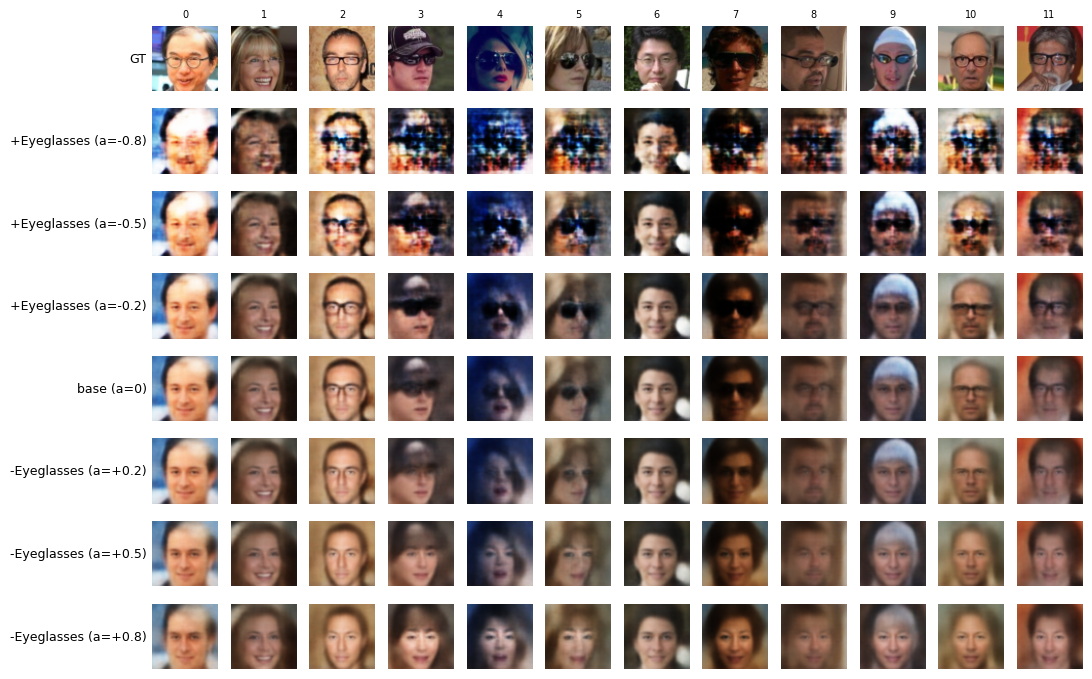

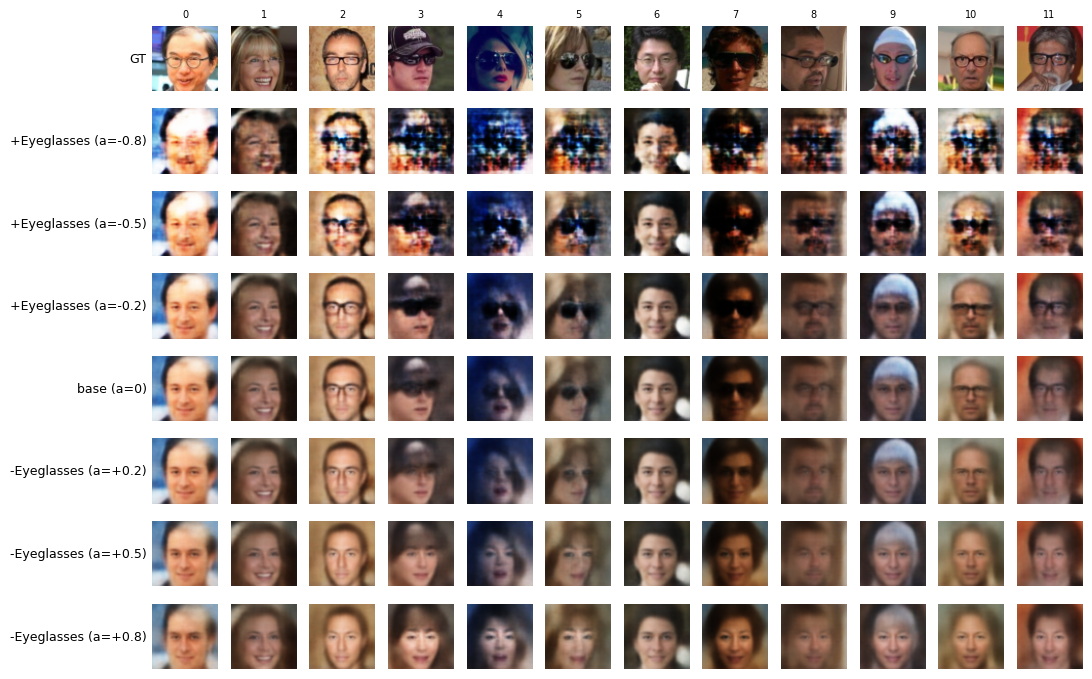

In [8]:
def sweep(attr, alphas, has_attr=True, n=12):
    W = engram_weight_for(attr)
    inputs = pick_faces(attr, has_attr=has_attr, n=n)
    rows = [('GT', inputs)]
    for a in alphas:
        if a == 0:
            rows.append(('base (a=0)', base_model.reconstruct(inputs)))
        else:
            em = _edit(base_model, W, alpha=a)
            label = f'-{attr} (a=+{a})' if a > 0 else f'+{attr} (a={a})'
            rows.append((label, em.reconstruct(inputs)))
    return _grid(rows)


# === choose what to inspect ===
SWEEP_ATTR = 'Eyeglasses'
ADD_ALPHAS = [-0.8, -0.5, -0.2]    # negative = ADD / intensify
SUB_ALPHAS = [0.2, 0.5, 0.8]        # positive = REMOVE
sweep(SWEEP_ATTR, ADD_ALPHAS + [0.0] + SUB_ALPHAS, has_attr=True, n=12)

## Step 2 - single-attribute showcase

`show(attr, alpha, has_attr=...)` renders GT / base / edited.
* To **showcase Eyeglasses**, start from real glasses-wearers (`has_attr=True`, the default)
  and use a positive alpha to **remove** them - the effect is clean and obvious.
* Use `has_attr=False` with a negative alpha to **add** the attribute to bare faces.

Files already downloaded and verified


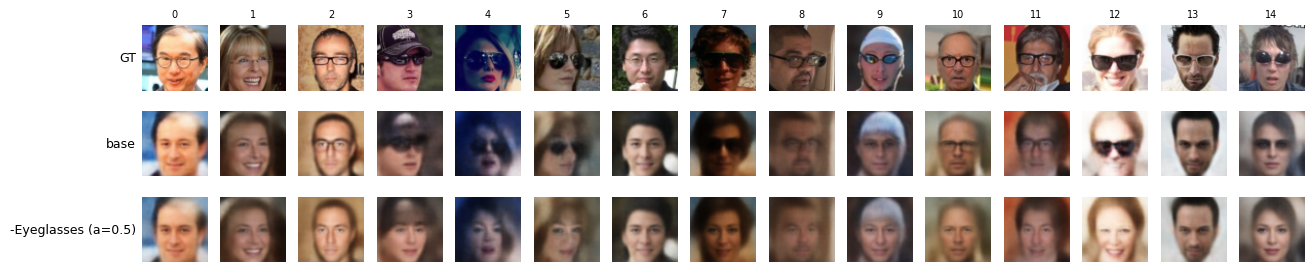

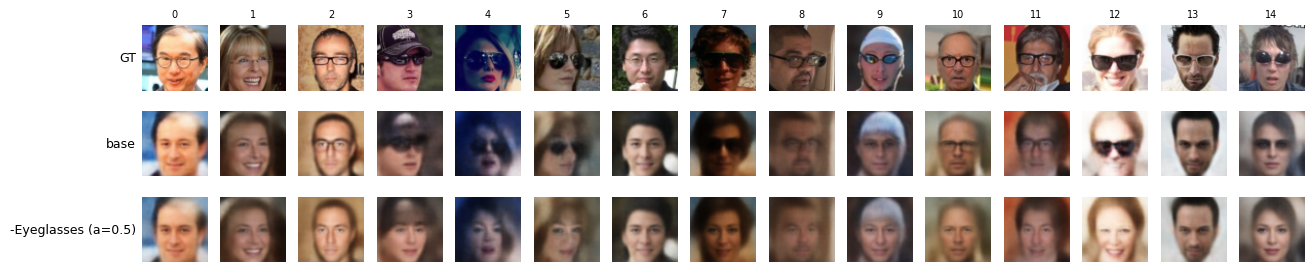

In [9]:
def show(attr, alpha, has_attr=True, n=15, select=None, save=True):
    W = engram_weight_for(attr)
    inputs = pick_faces(attr, has_attr=has_attr, n=n)
    em = _edit(base_model, W, alpha=alpha)
    op = f'-{attr}' if alpha > 0 else f'+{attr}'
    rows = [('GT', inputs),
            ('base', base_model.reconstruct(inputs)),
            (f'{op} (a={alpha})', em.reconstruct(inputs))]
    tag = 'have' if has_attr else 'none'
    return _grid(rows, select=select, save_name=(f'{op}_{tag}' if save else None))


# Eyeglasses example: show real glasses-wearers (label=1) and REMOVE the glasses
show('Eyeglasses', alpha=0.5, has_attr=True)

Files already downloaded and verified


using custom batch_fn


  0%|          | 0/8 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:00<00:03,  2.14it/s]

 38%|███▊      | 3/8 [00:00<00:00,  5.88it/s]

 62%|██████▎   | 5/8 [00:00<00:00,  7.65it/s]

100%|██████████| 8/8 [00:00<00:00, 11.82it/s]

100%|██████████| 8/8 [00:00<00:00,  8.27it/s]

engram weight ready: Goatee
Files already downloaded and verified


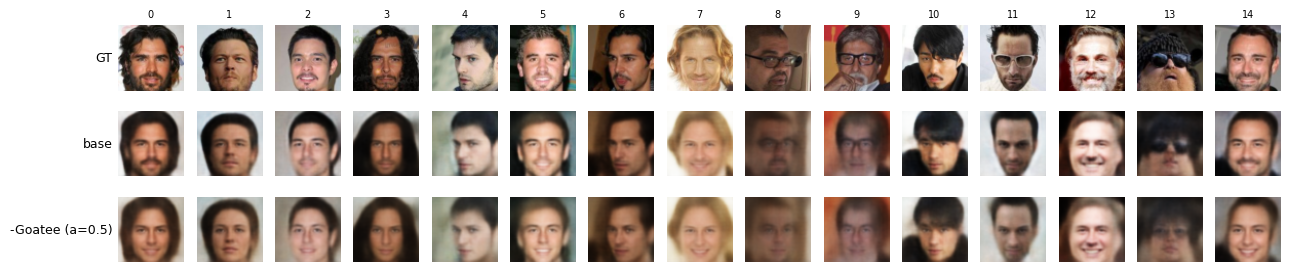

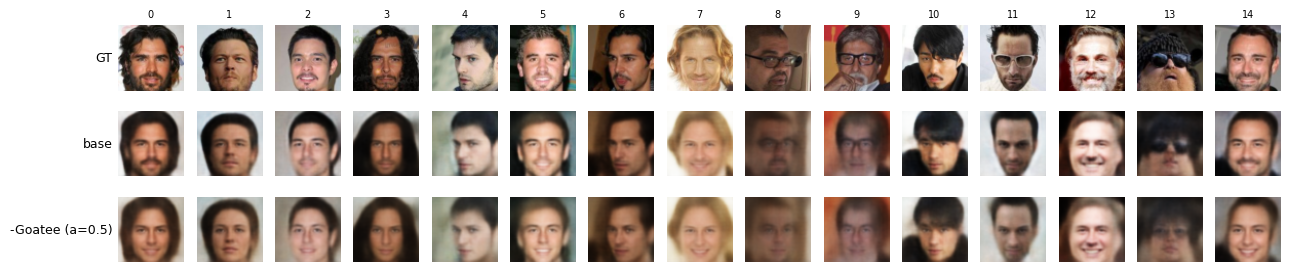

In [10]:
# Goatee example, same idea: real goatee faces (label=1), goatee removed
show('Goatee', alpha=0.5, has_attr=True)

## Step 3 - attribute arithmetic (combined add + subtract)

`arithmetic(ATTR_to_add, ATTR_to_sub, ...)` finds faces that **lack** `ATTR_to_add` and **have**
`ATTR_to_sub`, then shows GT / base / `+ATTR_to_add` / `-ATTR_to_sub` / `+ATTR_to_add -ATTR_to_sub`.

Files already downloaded and verified


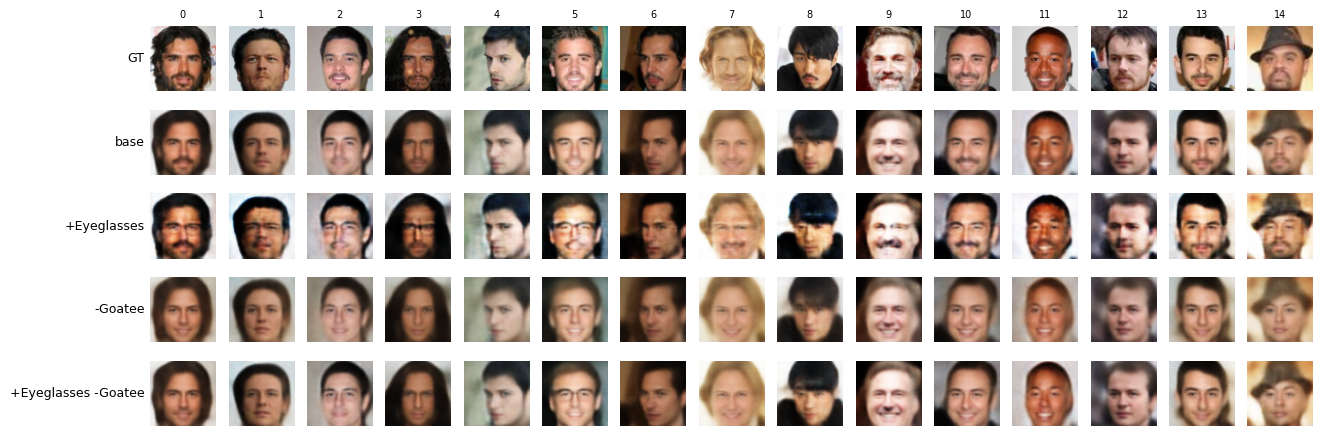

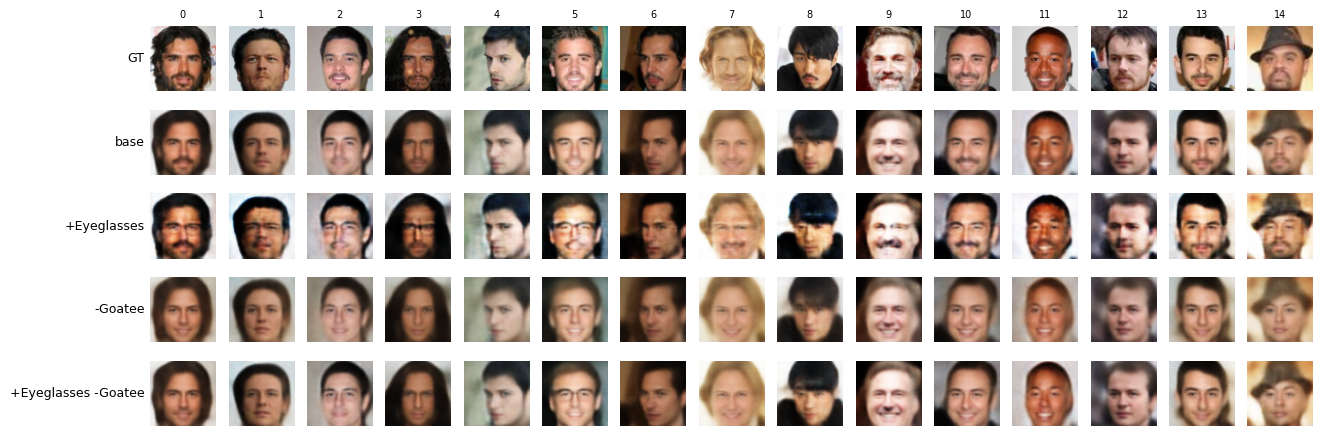

In [11]:
def arithmetic(ATTR_to_add, ATTR_to_sub, alpha_add=0.5, alpha_sub=0.5,
               n=15, select=None, batch_size=400):
    W_add = engram_weight_for(ATTR_to_add)
    W_sub = engram_weight_for(ATTR_to_sub)

    loader = celeba_attr(split='valid', batch_size=batch_size, root=DATA_ROOT, shuffle=False)
    inputs = None
    for x, labels in loader:
        cond = (labels[:, attrs.index(ATTR_to_add)] == False) & (labels[:, attrs.index(ATTR_to_sub)] == True)
        if cond.any():
            inputs = x[cond][:n].to(device)
            break
    if inputs is None:
        print('no matching faces found'); return None

    # Surgery (engram method, verbatim): add = -alpha, subtract = +alpha
    edit_model_add = _edit(base_model, W_add, alpha=-alpha_add)
    edit_model_sub = _edit(base_model, W_sub, alpha=+alpha_sub)
    edit_model_all = _edit(edit_model_add, W_sub, alpha=+alpha_sub)

    rows = [
        ('GT', inputs),
        ('base', base_model.reconstruct(inputs)),
        (f'+{ATTR_to_add}', edit_model_add.reconstruct(inputs)),
        (f'-{ATTR_to_sub}', edit_model_sub.reconstruct(inputs)),
        (f'+{ATTR_to_add} -{ATTR_to_sub}', edit_model_all.reconstruct(inputs)),
    ]
    return _grid(rows, select=select, save_name=f'+{ATTR_to_add}-{ATTR_to_sub}')


# === pick the strength from the sweep, and good columns via select=[...] ===
arithmetic('Eyeglasses', 'Goatee', alpha_add=0.5, alpha_sub=0.5, select=None)